In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000, centers=3,n_features=2)

In [3]:
X

array([[ 3.7373456 , -2.33026169],
       [ 4.98666377, -3.29073042],
       [ 9.51188502, -8.9468969 ],
       ...,
       [ 9.91156431, -7.63653834],
       [ 9.64301679, -7.8390754 ],
       [ 3.21319999, -1.7931463 ]])

In [4]:
y

array([0, 0, 2, 1, 2, 1, 0, 0, 0, 2, 0, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 1,
       1, 1, 0, 1, 2, 2, 0, 0, 1, 2, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2,
       2, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 2, 1, 2, 2, 1, 0, 0, 1, 2, 0, 2, 1, 1, 2, 1, 2, 0, 1, 0, 0,
       2, 0, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 2, 2, 0, 1, 2, 1, 0,
       1, 2, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0, 1, 2, 1, 1, 0, 0, 0,
       2, 1, 0, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 1, 1, 2, 0, 1, 1,
       2, 0, 2, 1, 1, 1, 0, 0, 1, 1, 1, 2, 0, 2, 2, 1, 0, 1, 0, 0, 1, 2,
       1, 2, 0, 2, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 2, 2, 0, 1, 2, 2, 2,
       1, 2, 2, 0, 1, 2, 0, 0, 0, 2, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 0, 1, 2, 0, 0, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 1,
       2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 2, 2, 1, 2,
       0, 1, 1, 1, 1, 2, 1, 2, 2, 0, 2, 1, 1, 2, 2, 0, 1, 0, 2, 2, 0, 1,
       2, 1, 1, 2, 1, 0, 0, 2, 1, 1, 2, 2, 2, 0, 1,

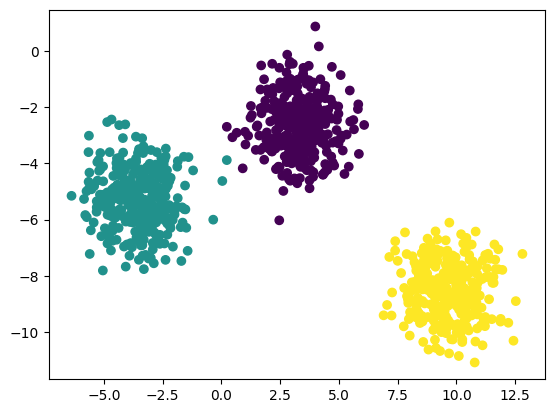

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization -- feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [8]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
## Elboe method to select the K-Value
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scale)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[1340.0000000000005,
 431.48832428740275,
 126.301308590692,
 101.27390430452365,
 82.46107430165273,
 59.479169865067234,
 66.58430816458608,
 47.52761522894707,
 42.06484933806541,
 39.22960941356364]

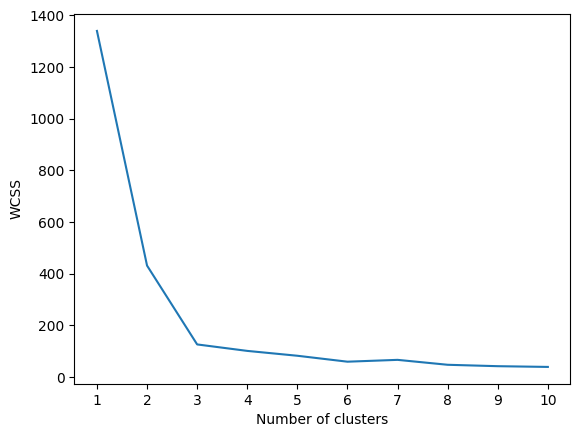

In [12]:
## plot Elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [14]:
kmeans.fit_predict(X_train_scale)

array([2, 1, 2, 1, 2, 1, 1, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2, 2, 0, 0, 0, 1,
       1, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 2, 0, 2, 1, 2, 2, 0, 0, 0, 1, 2,
       2, 1, 1, 2, 2, 0, 1, 2, 2, 1, 0, 2, 2, 1, 0, 1, 0, 0, 0, 0, 0, 2,
       2, 1, 1, 1, 2, 2, 0, 2, 0, 2, 1, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 1, 2, 1, 2, 1, 1, 0, 2, 0, 1, 1, 2, 0, 0, 0, 0,
       0, 0, 2, 2, 0, 2, 2, 0, 1, 0, 0, 2, 1, 0, 0, 1, 1, 1, 2, 1, 2, 2,
       1, 2, 2, 1, 1, 0, 2, 2, 0, 0, 0, 2, 0, 1, 1, 2, 1, 2, 0, 2, 0, 0,
       1, 1, 2, 0, 1, 1, 0, 2, 1, 0, 1, 2, 0, 1, 2, 0, 2, 1, 1, 0, 2, 0,
       2, 2, 0, 2, 0, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 2, 0, 0, 0, 0, 1, 1,
       1, 0, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1,
       1, 0, 0, 2, 1, 1, 2, 0, 0, 0, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2,
       2, 0, 1, 1, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1,
       2, 1, 0, 2, 0, 1, 2, 0, 0, 0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0, 2,
       0, 1, 0, 2, 2, 0, 0, 0, 1, 1, 1, 2, 1, 2, 0,

In [15]:
y_pred = kmeans.predict(X_test_scale)

In [16]:
y_pred

array([1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 2, 1, 2, 0, 0, 0, 1, 1, 0,
       0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0, 1,
       2, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0, 2, 2, 0, 1, 1, 0, 1, 1, 2, 2,
       0, 0, 1, 0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 0, 1, 0,
       0, 0, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2,
       0, 2, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 0, 2, 1, 2, 1, 2, 2,
       0, 1, 2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1, 2, 0, 1, 0,
       2, 2, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 1,
       1, 2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 2, 0, 1, 0, 2, 2, 1, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0, 1, 1, 2,
       2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 0, 1, 2, 2, 1, 1, 2, 0, 1, 1, 0, 2,
       0, 2, 0, 2, 2, 2, 2, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 0, 2, 1, 0, 0,
       1, 0, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 2,
       2, 2, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0, 2, 2, 1,

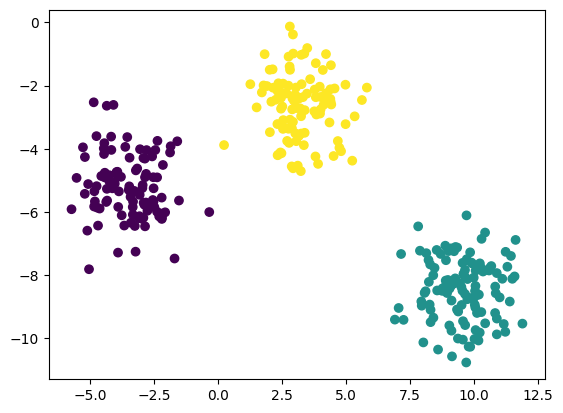

In [17]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [18]:
## validatin the k value
## kneelocator
## Silhoutee scoring

In [19]:
## kneelocator 
!pip install kneed

In [20]:
from kneed import KneeLocator

In [21]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [22]:
kl.elbow

np.int64(3)

In [23]:
## sillhoutte scoring
from sklearn.metrics import silhouette_score

In [24]:
silhouette_coefficent = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scale)
    score = silhouette_score(X_train_scale,kmeans.labels_)
    silhouette_coefficent.append(score)

In [25]:
silhouette_coefficent

[0.6468364662463075,
 0.7123828714918654,
 0.605363965164185,
 0.5775511164815799,
 0.43054218247162723,
 0.40183246109528176,
 0.3918127935120529,
 0.3729578328558371,
 0.3374921393291496]

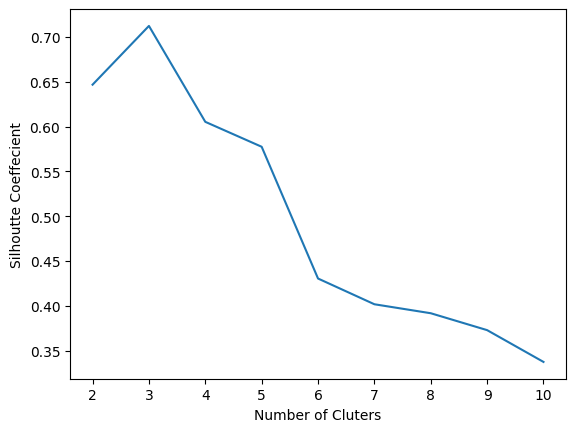

In [26]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficent)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()